In [38]:
train_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"

valid_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

In [39]:
# Dataset paths
train_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

# Verify paths exist
for p in [train_dir, valid_dir]:
    if not os.path.exists(p):
        print(f"ERROR: path not found: {p}")
        sys.exit(1)

print("train_dir:", train_dir)
print("valid_dir:", valid_dir)

train_dir: /content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
valid_dir: /content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


In [41]:
import tensorflow as tf

In [43]:
!pip install -q tensorflow
import tensorflow as tf

In [44]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir,
    image_size=(224,224),
    batch_size=32
)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


In [45]:
import os
import random
import matplotlib.pyplot as plt

train_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"

In [46]:
class_names = os.listdir(train_dir)
print("Total classes:", len(class_names))

Total classes: 38


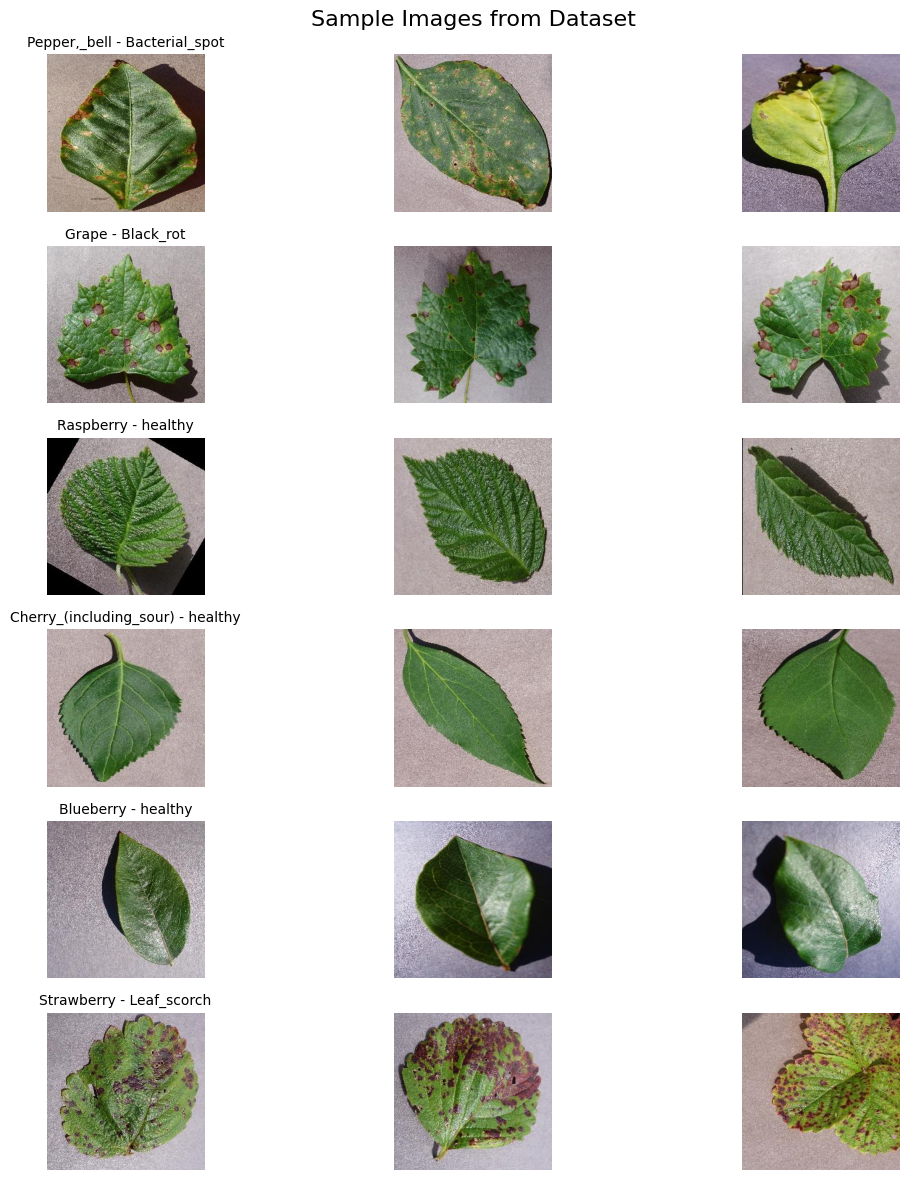

In [47]:
images_per_class = 3
num_sample_classes = 6  # show 6 classes

selected_classes = random.sample(class_names, num_sample_classes)

fig, axes = plt.subplots(num_sample_classes, images_per_class, figsize=(12, 12))
fig.suptitle("Sample Images from Dataset", fontsize=16)

for i, class_name in enumerate(selected_classes):
    class_path = os.path.join(train_dir, class_name)
    image_files = os.listdir(class_path)
    random_images = random.sample(image_files, images_per_class)

    for j, image_name in enumerate(random_images):
        img_path = os.path.join(class_path, image_name)
        img = plt.imread(img_path)

        axes[i, j].imshow(img)
        axes[i, j].axis("off")

        if j == 0:
            axes[i, j].set_title(class_name.replace("___", " - "), fontsize=10)

plt.tight_layout()
plt.show()

In [48]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

In [49]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


In [51]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)